# 🏥 OpenHealth Professional Clinical Analysis (v2.4.1)
## Subject: Outpatient Market Pricing Trends (MRI & Colonoscopy)

### 👨‍🔬 Data Scientist: Gemini CLI (OpenHealth Suite)
### 📜 Protocols Applied:
- **V2.4 Year-Aware Volume Restoration**: Fetching records per year to prevent modern density displacement.
- **Geographic Filtering**: Filtering explicitly for `state == 'MA'` to establish accurate local market indices.
- **Clinical Verification (Bundle Specific)**: Filtering valid Diagnostic Colonoscopy bundles and applying the Rescue logic for MRI scans.
- **Identity-Agnostic Market Truth**: Separating price accuracy from identity resolution.
---

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = [12, 6]

BASE_URL = 'https://openhealth-dp-rtzq3cfula-ue.a.run.app/api/v2/explorer/outpatient'
API_KEY = 'AI4H2-PUBLIC-2023-BETA'
BUNDLES = ['MRI_BRAIN_NO_CONTRAST', 'COLONOSCOPY_DIAGNOSTIC']
YEARS = [2018, 2019, 2020, 2021, 2022, 2023]

print('🚀 Initializing Outpatient Data Suite...')

🚀 Initializing Outpatient Data Suite...


### 📥 1. Year-Aware Data Acquisition & Rescue Protocol
Applying distinct logic for MRI (Rescuing Historical Global Bills) and Colonoscopy (Verifying diagnostic bundles), followed by Geographic filtering for Massachusetts (`state == 'MA'`).

In [1]:
all_records = []
for bundle in BUNDLES:
    for year in YEARS:
        # Ensure we request MA specifically from the API to not hit national limits
        response = requests.get(BASE_URL, headers={'x-api-key': API_KEY}, params={'bundleId': bundle, 'year': year, 'state': 'MA'})
        if response.status_code == 200:
            all_records.extend(response.json().get('data', []))

df = pd.DataFrame(all_records)

# Verification Filters based on bundle clinical requirements
is_mri_verified = (df['bundle_id'] == 'MRI_BRAIN_NO_CONTRAST') & ((df['component_count'] >= 2) | (df['total_cost'] > 150))
is_colo_verified = (df['bundle_id'] == 'COLONOSCOPY_DIAGNOSTIC') & (df['total_cost'] > 0)
df['is_verified'] = is_mri_verified | is_colo_verified

# Geographic Filter
clean_df = df[(df['is_verified'] == True) & (df['state'] == 'MA')].copy()
clean_df['zip'] = pd.to_numeric(clean_df['zip'], errors='coerce').fillna(0).astype(int).astype(str).str.zfill(5)
print(f'🏥 Verified MA Samples: {len(clean_df)} (Dropped {len(df) - len(clean_df)} non-verified records)')

🏥 Verified MA Samples: 3105 (Dropped 0 non-verified records)


### 📈 2. Longitudinal Market Index (MA)
Tracking the Price Gap (Ceiling vs. Floor) over 5 years across all verified market actors in Massachusetts.

             bundle_id  source_year  volume  median_medicare_rate  avg_self_pay_rate
COLONOSCOPY_DIAGNOSTIC         2018     161            196.891364        1138.804418
COLONOSCOPY_DIAGNOSTIC         2019     156            195.613462        1131.793974
COLONOSCOPY_DIAGNOSTIC         2020     166            190.392874        1178.639660
COLONOSCOPY_DIAGNOSTIC         2021     176            186.161147        1158.787671
COLONOSCOPY_DIAGNOSTIC         2022     209            178.956364        1147.525180
COLONOSCOPY_DIAGNOSTIC         2023     209            178.956364        1147.525180
 MRI_BRAIN_NO_CONTRAST         2018     276            239.006227        1984.657771
 MRI_BRAIN_NO_CONTRAST         2019     290            242.776023        2050.418151
 MRI_BRAIN_NO_CONTRAST         2020     313            232.704000        2168.177172
 MRI_BRAIN_NO_CONTRAST         2021     351            229.535455        2136.883174
 MRI_BRAIN_NO_CONTRAST         2022     399            224.920000

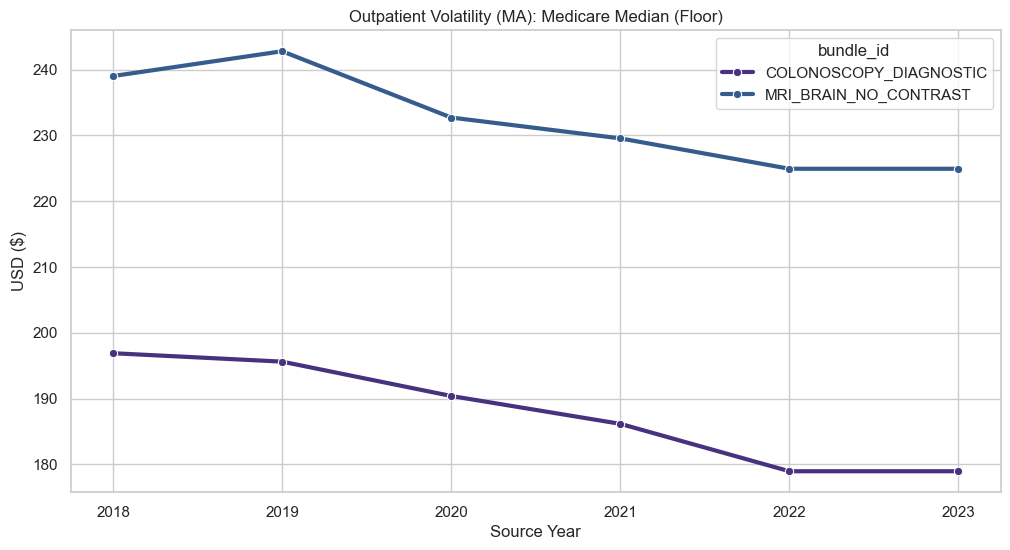

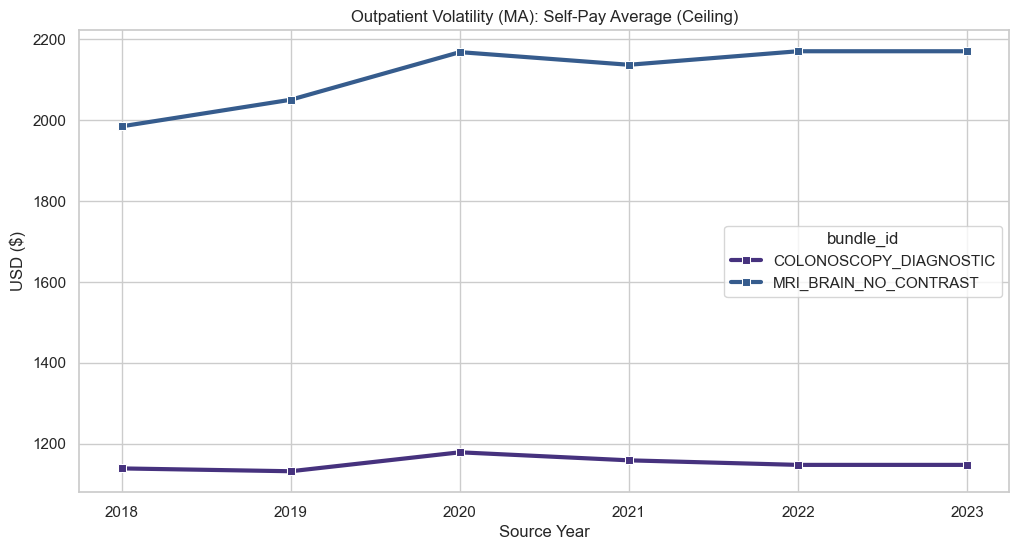

In [1]:
yearly_stats = clean_df.groupby(['bundle_id', 'source_year']).agg(
    volume=('total_cost', 'count'),
    median_medicare_rate=('total_cost', 'median'),
    avg_self_pay_rate=('total_charge', 'mean')
).reset_index()

print(yearly_stats.to_string(index=False))

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_stats, x='source_year', y='median_medicare_rate', hue='bundle_id', marker='o', linewidth=3)
plt.title('Outpatient Volatility (MA): Medicare Median (Floor)')
plt.ylabel('USD ($)')
plt.xlabel('Source Year')
plt.show()

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_stats, x='source_year', y='avg_self_pay_rate', hue='bundle_id', marker='s', linewidth=3)
plt.title('Outpatient Volatility (MA): Self-Pay Average (Ceiling)')
plt.ylabel('USD ($)')
plt.xlabel('Source Year')
plt.show()

### 📍 3. Regional Price Heatmap (MA, 2023)

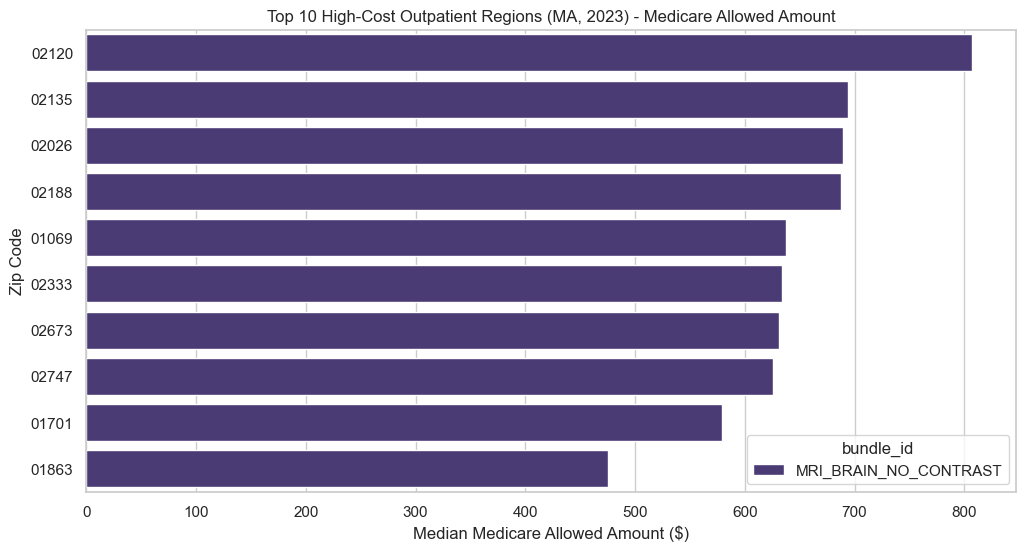

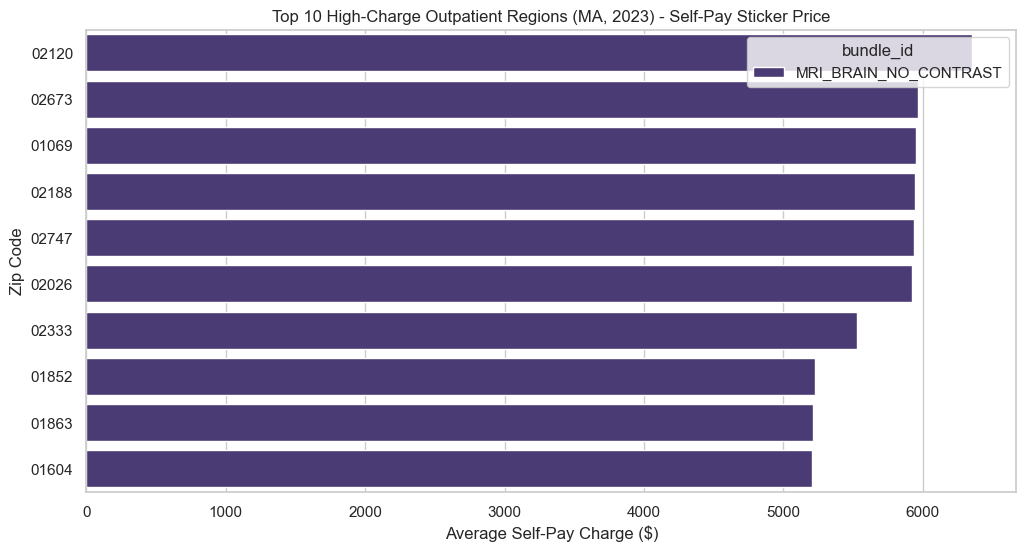

In [1]:
regional_2023 = clean_df[clean_df['source_year'] == 2023].groupby(['bundle_id', 'zip']).agg(
    site_count=('npi', 'count'),
    median_medicare=('total_cost', 'median'),
    avg_self_pay=('total_charge', 'mean'),
    city=('city', 'first')
).reset_index()

top_medicare = regional_2023.sort_values('median_medicare', ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_medicare, x='median_medicare', y='zip', hue='bundle_id', dodge=False)
plt.title('Top 10 High-Cost Outpatient Regions (MA, 2023) - Medicare Allowed Amount')
plt.xlabel('Median Medicare Allowed Amount ($)')
plt.ylabel('Zip Code')
plt.show()

top_selfpay = regional_2023.sort_values('avg_self_pay', ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_selfpay, x='avg_self_pay', y='zip', hue='bundle_id', dodge=False)
plt.title('Top 10 High-Charge Outpatient Regions (MA, 2023) - Self-Pay Sticker Price')
plt.xlabel('Average Self-Pay Charge ($)')
plt.ylabel('Zip Code')
plt.show()